<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">08. Damage Amplification via f(R) Propagation</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Propagates MPI rainfall distributions (anthropogenic and natural-forcing) through the fitted f(R) to obtain regional damage amplification ratios (Delta). Where f(R) is unreliable (IGP), Delta is derived from PR under the FAR x AAL fallback's implicit linear assumption instead. Before propagation, the MPI rainfall samples are checked against the ERA5-observed range that f(R) was calibrated on, since values beyond this range represent extrapolation of the fitted curve.</p>
</div>

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
REGION_ORDER = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']

fR_params = pd.read_csv(OUTPUT_DIR + 'fR_fitted_parameters.csv')
fR_input = pd.read_csv(OUTPUT_DIR + 'fR_input_data.csv')

ant_samples = xr.open_dataset(OUTPUT_DIR + 'pr_far_windowed_samples_ant.nc')
nat_samples = xr.open_dataset(OUTPUT_DIR + 'pr_far_windowed_samples_nat.nc')

# Use the corrected PR-first results, not the original average-first version.
# IGP's fallback (Delta=PR) should reflect the corrected method, same as everywhere else
pr_df_prfirst = pd.read_csv(OUTPUT_DIR + 'pr_far_rolling_window_results_PRFIRST.csv')

PRESENT_DAY_WINDOW = 2005  # centred 2005, covering 1995-2014

print(fR_params)

                region         form     intercept      slope        r2  n_obs  \
0        Central_India  exponential  2.913800e+01   0.021096  0.163407     21   
1  Indo_Gangetic_Plain       linear  1.395255e+04 -47.409101  0.004655     21   
2            Northeast       linear -4.525670e+03  30.391019  0.098390     21   
3        Western_Ghats        power  2.222550e-33  16.010127  0.380193     20   

    boot_ci_5  boot_ci_95  n_boot_failed  use_fallback  
0    0.008075    0.041860              0         False  
1 -265.507811  157.015507              0          True  
2    8.035641   64.029190              0         False  
3    5.010176   34.686378             75         False  


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 1: Extrapolation Check</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">For each region with a fitted f(R) (i.e. not IGP), checks what fraction of the 600 present-day anthropogenic-world MPI samples fall outside the ERA5-observed Rx5day range that f(R) was calibrated on. A high fraction indicates the fitted curve is being extrapolated beyond its validated range.</p>
</div>

In [2]:
FR_REGIONS = [r for r in REGION_ORDER if r != 'Indo_Gangetic_Plain']

extrap_records = []
for region in FR_REGIONS:
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    obs_min, obs_max = obs.min(), obs.max()

    ant_vals = ant_samples['rx5day_ant_windowed'].sel(
        window_centre_year=PRESENT_DAY_WINDOW, region=region).values

    n_below = np.sum(ant_vals < obs_min)
    n_above = np.sum(ant_vals > obs_max)
    n_outside = n_below + n_above
    pct_outside = 100 * n_outside / len(ant_vals)

    extrap_records.append({
        'region': region,
        'ERA5_obs_min': obs_min, 'ERA5_obs_max': obs_max,
        'MPI_ant_min': ant_vals.min(), 'MPI_ant_max': ant_vals.max(),
        'n_below_range': n_below, 'n_above_range': n_above,
        'pct_outside_range': pct_outside
    })

extrap_df = pd.DataFrame(extrap_records)
print(extrap_df.to_string(index=False))

       region  ERA5_obs_min  ERA5_obs_max  MPI_ant_min  MPI_ant_max  n_below_range  n_above_range  pct_outside_range
Central_India    141.119373    227.595961    88.208368   155.926270            580              0          96.666667
    Northeast    201.404834    328.905679   101.001418   220.627874            593              0          98.833333
Western_Ghats    133.382511    201.341153    62.563768   170.029359            597              0          99.500000


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 2: Bias Correction (MPI vs ERA5)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Derives a multiplicative bias-correction factor per region by comparing the MPI anthropogenic-world ensemble mean Rx5day against the ERA5-observed mean, over their overlapping period (2000-2014). This corrects for MPI's dry bias/synoptic variance underestimation before propagating rainfall through f(R), which was calibrated on ERA5's absolute rainfall scale. The same correction factor is applied to both ant and nat present-day samples, since the bias is a model characteristic rather than a forcing-world-specific effect.</p>
</div>

In [3]:
rx5day_ant_full = xr.open_dataset(OUTPUT_DIR + 'rx5day_ant_regional.nc')

OVERLAP_YEARS = slice(2000, 2014)

bias_records = []
for region in FR_REGIONS:
    region_idx = REGION_ORDER.index(region)

    mpi_overlap = rx5day_ant_full['rx5day_ant_regional'].isel(region=region_idx).sel(
        year=OVERLAP_YEARS).values.flatten()
    mpi_mean = np.mean(mpi_overlap)

    era5_overlap = fR_input[(fR_input.region == region) &
                             (fR_input.year >= 2000) & (fR_input.year <= 2014)]['rx5day_mm']
    era5_mean = era5_overlap.mean()

    scale_factor = era5_mean / mpi_mean

    bias_records.append({
        'region': region, 'MPI_mean_2000_2014': mpi_mean, 'ERA5_mean_2000_2014': era5_mean,
        'scale_factor': scale_factor, 'n_era5_years': len(era5_overlap)
    })

bias_df = pd.DataFrame(bias_records)
print(bias_df.to_string(index=False))

       region  MPI_mean_2000_2014  ERA5_mean_2000_2014  scale_factor  n_era5_years
Central_India          120.180919           193.080076      1.606578            15
    Northeast          142.570709           261.235510      1.832322            15
Western_Ghats           94.036232           172.942060      1.839100            15


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 3: Apply Bias Correction and Re-check Extrapolation</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Applies the regional scale factor from Part 2 to the present-day (window centred 2005) MPI ant and nat samples, then re-runs the extrapolation check from Part 1 to confirm the correction brings the samples into (or closer to) the ERA5-observed range that f(R) was calibrated on.</p>
</div>

In [4]:
corrected_ant = {}
corrected_nat = {}

for region in FR_REGIONS:
    scale = bias_df[bias_df.region == region]['scale_factor'].values[0]

    ant_vals = ant_samples['rx5day_ant_windowed'].sel(
        window_centre_year=PRESENT_DAY_WINDOW, region=region).values
    nat_vals = nat_samples['rx5day_nat_windowed'].sel(
        window_centre_year=PRESENT_DAY_WINDOW, region=region).values

    corrected_ant[region] = ant_vals * scale
    corrected_nat[region] = nat_vals * scale

# re-check extrapolation using corrected values
recheck_records = []
for region in FR_REGIONS:
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    obs_min, obs_max = obs.min(), obs.max()

    vals = corrected_ant[region]
    n_below = np.sum(vals < obs_min)
    n_above = np.sum(vals > obs_max)
    pct_outside = 100 * (n_below + n_above) / len(vals)

    recheck_records.append({
        'region': region, 'ERA5_obs_min': obs_min, 'ERA5_obs_max': obs_max,
        'corrected_MPI_ant_min': vals.min(), 'corrected_MPI_ant_max': vals.max(),
        'pct_outside_range': pct_outside
    })

recheck_df = pd.DataFrame(recheck_records)
print(recheck_df.to_string(index=False))

       region  ERA5_obs_min  ERA5_obs_max  corrected_MPI_ant_min  corrected_MPI_ant_max  pct_outside_range
Central_India    141.119373    227.595961             141.713665             250.507787           2.666667
    Northeast    201.404834    328.905679             185.067165             404.261406           6.333333
Western_Ghats    133.382511    201.341153             115.061042             312.701040          10.500000


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 4: Propagate Rainfall Through f(R)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Evaluates each region's fitted f(R) on the bias-corrected present-day MPI samples (600 per forcing world), producing simulated damage values D_i. Checks for physically impossible negative damage predictions (a risk for the linear form, per the positivity constraint applied in notebook 06) before computing expected damage and the amplification ratio.</p>
</div>

In [5]:
def evaluate_fR(region, R_values, params_df):
    row = params_df[params_df.region == region].iloc[0]
    form = row['form']
    if form == 'linear':
        return row['intercept'] + row['slope'] * R_values
    elif form == 'exponential':
        return row['intercept'] * np.exp(row['slope'] * R_values)
    elif form == 'power':
        return row['intercept'] * np.power(R_values, row['slope'])

propagation_records = []
for region in FR_REGIONS:
    D_ant = evaluate_fR(region, corrected_ant[region], fR_params)
    D_nat = evaluate_fR(region, corrected_nat[region], fR_params)

    n_neg_ant = np.sum(D_ant < 0)
    n_neg_nat = np.sum(D_nat < 0)

    E_D_ant = np.mean(D_ant)
    E_D_nat = np.mean(D_nat)
    delta = E_D_ant / E_D_nat

    propagation_records.append({
        'region': region, 'form': fR_params[fR_params.region == region]['form'].values[0],
        'E_D_ant': E_D_ant, 'E_D_nat': E_D_nat, 'delta': delta,
        'n_negative_D_ant': n_neg_ant, 'n_negative_D_nat': n_neg_nat,
        'D_ant_min': D_ant.min(), 'D_nat_min': D_nat.min()
    })

propagation_df = pd.DataFrame(propagation_records)
print(propagation_df.to_string(index=False))

       region        form      E_D_ant      E_D_nat    delta  n_negative_D_ant  n_negative_D_nat   D_ant_min   D_nat_min
Central_India exponential  1803.278383  1719.473015 1.048739                 0                 0  579.190882  619.322769
    Northeast      linear  3422.513998  3370.393824 1.015464                 0                 0 1098.709738 1330.073692
Western_Ghats       power 47073.916452 10393.502253 4.529168                 0                 0    2.200775    0.555004


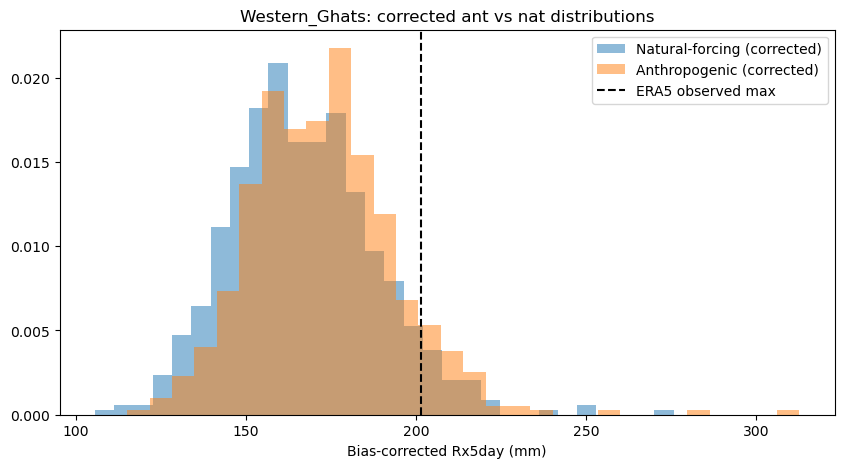

ant mean/max: 172.69146875701315 312.70104014529346
nat mean/max: 166.95179161740975 275.7242758073749


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(corrected_nat['Western_Ghats'], bins=30, alpha=0.5, label='Natural-forcing (corrected)', density=True)
ax.hist(corrected_ant['Western_Ghats'], bins=30, alpha=0.5, label='Anthropogenic (corrected)', density=True)
ax.axvline(fR_input[fR_input.region == 'Western_Ghats']['rx5day_mm'].max(),
           color='black', linestyle='--', label='ERA5 observed max')
ax.legend()
ax.set_xlabel('Bias-corrected Rx5day (mm)')
ax.set_title('Western_Ghats: corrected ant vs nat distributions')
plt.show()

print("ant mean/max:", corrected_ant['Western_Ghats'].mean(), corrected_ant['Western_Ghats'].max())
print("nat mean/max:", corrected_nat['Western_Ghats'].mean(), corrected_nat['Western_Ghats'].max())

In [7]:
D_ant_wg = evaluate_fR('Western_Ghats', corrected_ant['Western_Ghats'], fR_params)

# sort descending, look at cumulative contribution to the mean
sorted_D = np.sort(D_ant_wg)[::-1]
top_5_share = sorted_D[:5].sum() / sorted_D.sum() * 100
top_10_share = sorted_D[:10].sum() / sorted_D.sum() * 100

print(f"Top 5 samples (of 600) contribute {top_5_share:.1f}% of E[D_ant]")
print(f"Top 10 samples (of 600) contribute {top_10_share:.1f}% of E[D_ant]")
print(f"Largest 5 D values: {sorted_D[:5]}")

Top 5 samples (of 600) contribute 88.9% of E[D_ant]
Top 10 samples (of 600) contribute 90.6% of E[D_ant]
Largest 5 D values: [19687438.66698829  4254697.9857502    771308.89986328   230567.73818128
   159777.20176715]


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 4b: Cap Extrapolated Samples Before Propagation</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Caps bias-corrected rainfall samples at the ERA5-observed min/max per region before evaluating f(R), preventing unbounded extrapolation beyond the calibrated range. Binds most often for Western Ghats (10.5% of samples), whose Delta should be read as a lower bound as a result.</p>
</div>

In [8]:
def cap_to_observed_range(values, region):
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    return np.clip(values, obs.min(), obs.max())

capped_ant = {r: cap_to_observed_range(corrected_ant[r], r) for r in FR_REGIONS}
capped_nat = {r: cap_to_observed_range(corrected_nat[r], r) for r in FR_REGIONS}

capped_records = []
for region in FR_REGIONS:
    D_ant = evaluate_fR(region, capped_ant[region], fR_params)
    D_nat = evaluate_fR(region, capped_nat[region], fR_params)

    E_D_ant, E_D_nat = np.mean(D_ant), np.mean(D_nat)
    delta = E_D_ant / E_D_nat

    n_capped_ant = np.sum(corrected_ant[region] != capped_ant[region])
    n_capped_nat = np.sum(corrected_nat[region] != capped_nat[region])

    capped_records.append({
        'region': region, 'E_D_ant': E_D_ant, 'E_D_nat': E_D_nat, 'delta': delta,
        'pct_capped_ant': 100*n_capped_ant/600, 'pct_capped_nat': 100*n_capped_nat/600
    })

capped_df = pd.DataFrame(capped_records)
print(capped_df.to_string(index=False))

       region     E_D_ant     E_D_nat    delta  pct_capped_ant  pct_capped_nat
Central_India 1788.013560 1705.940746 1.048110        2.666667        1.500000
    Northeast 3383.727846 3363.023804 1.006156        6.333333        4.166667
Western_Ghats 3719.721248 2858.593462 1.301242       10.500000       10.333333


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 5: Combine All Four Regions</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Merges the f(R)-propagated Delta values (Central India, Northeast, Western Ghats) with Indo-Gangetic Plain's Delta, derived as Delta=PR under the FAR x AAL fallback's implicit linear damage-probability assumption. A method flag distinguishes the two derivations, since IGP's Delta carries no information about damage non-linearity, unlike the other three regions.</p>
</div>

In [9]:
igp_pr = pr_df_prfirst[(pr_df_prfirst.region == 'Indo_Gangetic_Plain') & (pr_df_prfirst.year == PRESENT_DAY_WINDOW)].iloc[0]

igp_row = pd.DataFrame([{
    'region': 'Indo_Gangetic_Plain',
    'E_D_ant': np.nan,
    'E_D_nat': np.nan,
    'delta': igp_pr['PR'],
    'pct_capped_ant': np.nan,
    'pct_capped_nat': np.nan
}])

delta_results = pd.concat([capped_df, igp_row], ignore_index=True)
delta_results['method'] = delta_results['region'].apply(
    lambda r: 'FAR x AAL fallback (Delta=PR)' if r == 'Indo_Gangetic_Plain' else 'f(R) propagation'
)

delta_results['region'] = pd.Categorical(delta_results['region'], categories=REGION_ORDER, ordered=True)
delta_results = delta_results.sort_values('region').reset_index(drop=True)

print(delta_results.to_string(index=False))

             region     E_D_ant     E_D_nat    delta  pct_capped_ant  pct_capped_nat                        method
      Central_India 1788.013560 1705.940746 1.048110        2.666667        1.500000              f(R) propagation
Indo_Gangetic_Plain         NaN         NaN 1.232232             NaN             NaN FAR x AAL fallback (Delta=PR)
          Northeast 3383.727846 3363.023804 1.006156        6.333333        4.166667              f(R) propagation
      Western_Ghats 3719.721248 2858.593462 1.301242       10.500000       10.333333              f(R) propagation


In [10]:
import pandas as pd

fR_input = pd.read_csv(OUTPUT_DIR + 'fR_input_data.csv')
delta_results_saved = pd.read_csv(OUTPUT_DIR + 'damage_amplification_results.csv')

print(f"{'Region':<18} {'Cap min (mm)':<14} {'Cap max (mm)':<14} {'% capped ant':<14} {'% capped nat'}")
for region in ['Central_India', 'Northeast', 'Western_Ghats']:
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    row = delta_results_saved[delta_results_saved.region == region].iloc[0]
    print(f"{region:<18} {obs.min():<14.2f} {obs.max():<14.2f} {row['pct_capped_ant']:<14.2f} {row['pct_capped_nat']:.2f}")

Region             Cap min (mm)   Cap max (mm)   % capped ant   % capped nat
Central_India      141.12         227.60         2.67           1.50
Northeast          201.40         328.91         6.33           4.17
Western_Ghats      133.38         201.34         10.50          10.33


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 6: Bootstrap Confidence Intervals for Delta</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Resamples ensemble members with replacement (1000 iterations) for the present-day window, re-applying bias correction, capping, and f(R) propagation each iteration, to quantify uncertainty in Delta. IGP's Delta (=PR) reuses the bootstrap already computed in notebook 07 for the same window, since it is not derived via f(R).</p>
</div>

In [11]:
rx5day_ant = xr.open_dataset(OUTPUT_DIR + 'rx5day_ant_regional.nc')
rx5day_nat = xr.open_dataset(OUTPUT_DIR + 'rx5day_nat_regional.nc')

In [12]:
N_BOOT = 1000
np.random.seed(42)

# raw (uncorrected) present-day member-structured samples: shape (30 members, 20 years) per region
def get_member_window(ds, varname, region_idx, t):
    return ds[varname].isel(region=region_idx).sel(
        year=slice(t - 10, t + 9)).values  # shape (30, 20)

bootstrap_delta = {region: np.full(N_BOOT, np.nan) for region in FR_REGIONS}

for region in FR_REGIONS:
    region_idx = REGION_ORDER.index(region)
    scale = bias_df[bias_df.region == region]['scale_factor'].values[0]
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    obs_min, obs_max = obs.min(), obs.max()

    ant_raw = get_member_window(rx5day_ant, 'rx5day_ant_regional', region_idx, PRESENT_DAY_WINDOW)
    nat_raw = get_member_window(rx5day_nat, 'rx5day_nat_regional', region_idx, PRESENT_DAY_WINDOW)
    n_members = ant_raw.shape[0]

    for i in range(N_BOOT):
        idx = np.random.choice(n_members, size=n_members, replace=True)

        ant_boot = (ant_raw[idx] * scale).flatten()
        nat_boot = (nat_raw[idx] * scale).flatten()

        ant_boot_capped = np.clip(ant_boot, obs_min, obs_max)
        nat_boot_capped = np.clip(nat_boot, obs_min, obs_max)

        D_ant = evaluate_fR(region, ant_boot_capped, fR_params)
        D_nat = evaluate_fR(region, nat_boot_capped, fR_params)

        bootstrap_delta[region][i] = np.mean(D_ant) / np.mean(D_nat)

delta_ci_records = []
for region in FR_REGIONS:
    lo, hi = np.nanpercentile(bootstrap_delta[region], [5, 95])
    delta_ci_records.append({'region': region, 'delta_ci_5': lo, 'delta_ci_95': hi})

# IGP reuses its PR bootstrap from notebook 07 (corrected PR-first version)
delta_ci_records.append({
    'region': 'Indo_Gangetic_Plain',
    'delta_ci_5': igp_pr['PR_ci_5'], 'delta_ci_95': igp_pr['PR_ci_95']
})

delta_ci_df = pd.DataFrame(delta_ci_records)
delta_results = delta_results.merge(delta_ci_df, on='region')
print(delta_results[['region', 'delta', 'delta_ci_5', 'delta_ci_95', 'method']].to_string(index=False))

             region    delta  delta_ci_5  delta_ci_95                        method
      Central_India 1.048110    1.020233     1.076528              f(R) propagation
Indo_Gangetic_Plain 1.232232    1.142625     1.367198 FAR x AAL fallback (Delta=PR)
          Northeast 1.006156    0.981064     1.034153              f(R) propagation
      Western_Ghats 1.301242    1.159800     1.455285              f(R) propagation


In [13]:
print(f"Western Ghats Δ bootstrap: {np.sum(np.isnan(bootstrap_delta['Western_Ghats']))} failed out of {len(bootstrap_delta['Western_Ghats'])}")

Western Ghats Δ bootstrap: 0 failed out of 1000


In [14]:
region = 'Western_Ghats'
region_idx = REGION_ORDER.index(region)
scale = bias_df[bias_df.region == region]['scale_factor'].values[0]

ant_raw = get_member_window(rx5day_ant, 'rx5day_ant_regional', region_idx, PRESENT_DAY_WINDOW)
ant_true = (ant_raw * scale).flatten()  # genuine 30x20=600 samples, no resampling

print(f"Unique values: {len(np.unique(ant_true))} out of {len(ant_true)}")

D_ant_true = evaluate_fR(region, ant_true, fR_params)
D_ant_sorted = np.sort(D_ant_true)[::-1]

top5_sum = D_ant_sorted[:5].sum()
total_sum = D_ant_sorted.sum()
print(f"Top 5 samples: {D_ant_sorted[:5]}")
print(f"% of total from top 5: {100 * top5_sum / total_sum:.1f}%")
print(f"Mean (uncapped E[D_ant]): {D_ant_true.mean():.1f}")
print(f"Top 1: {D_ant_sorted[0]:,.1f} = {100 * D_ant_sorted[0] / total_sum:.1f}% of total")
print(f"Total sum (n={len(D_ant_true)}): {total_sum:,.1f}")

Unique values: 600 out of 600
Top 5 samples: [19687438.66698829  4254697.9857502    771308.89986328   230567.73818128
   159777.20176715]
% of total from top 5: 88.9%
Mean (uncapped E[D_ant]): 47073.9
Top 1: 19,687,438.7 = 69.7% of total
Total sum (n=600): 28,244,349.9


In [15]:
nat_raw = get_member_window(rx5day_nat, 'rx5day_nat_regional', region_idx, PRESENT_DAY_WINDOW)
nat_true = (nat_raw * scale).flatten()
D_nat_true = evaluate_fR(region, nat_true, fR_params)

print(f"uncapped delta = {D_ant_true.mean() / D_nat_true.mean():.6f}")
print(f"hardcoded      = 4.529168")
print(f"E[D_nat] uncapped = {D_nat_true.mean():,.1f}")

uncapped delta = 4.529168
hardcoded      = 4.529168
E[D_nat] uncapped = 10,393.5


In [16]:
# Pull each region's PR at the present-day window and merge into delta_results
pr_present_df = pr_df_prfirst[pr_df_prfirst.year == PRESENT_DAY_WINDOW][['region', 'PR']].rename(
    columns={'PR': 'PR_present'}
)

delta_results = delta_results.merge(pr_present_df, on='region')

# Rank columns for the CSV export in the final cell (1 = highest amplification/PR)
delta_results['delta_rank'] = delta_results['delta'].rank(ascending=False).astype(int)
delta_results['PR_rank'] = delta_results['PR_present'].rank(ascending=False).astype(int)

# Re-apply region ordering (merge can disturb categorical order)
delta_results['region'] = pd.Categorical(delta_results['region'], categories=REGION_ORDER, ordered=True)
delta_results = delta_results.sort_values('region').reset_index(drop=True)

print(delta_results[['region', 'PR_present', 'delta', 'delta_ci_5', 'delta_ci_95', 'delta_rank', 'PR_rank']].to_string(index=False))

             region  PR_present    delta  delta_ci_5  delta_ci_95  delta_rank  PR_rank
      Central_India    1.175537 1.048110    1.020233     1.076528           3        4
Indo_Gangetic_Plain    1.232232 1.232232    1.142625     1.367198           2        3
          Northeast    1.366995 1.006156    0.981064     1.034153           4        1
      Western_Ghats    1.328223 1.301242    1.159800     1.455285           1        2


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 7: Figure - Magnitude of the 1-in-10-Year Rx5day Event Over Time (Figure 12)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Companion figure: shows the underlying rainfall magnitude driving the results elsewhere in this notebook, tracking how the actual Rx5day level at each region's 1-in-10-year threshold moves over time, before the reader sees this reframed as a fixed-threshold exceedance probability (PR) or propagated damage ratio (Delta). Self-contained, reloads windowed samples directly rather than depending on earlier cells.</p>
</div>

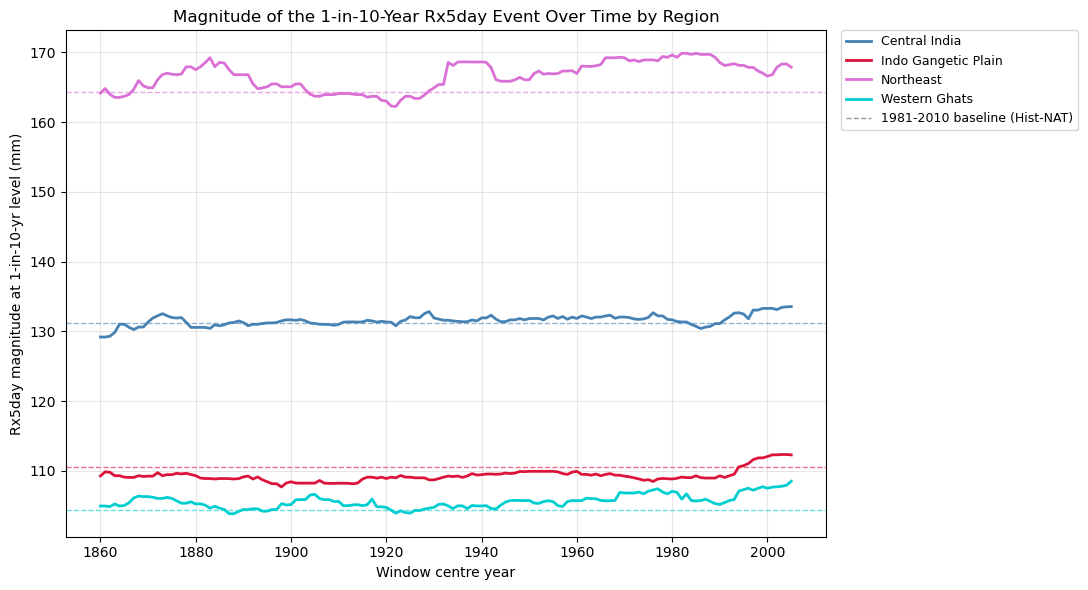

In [44]:
from matplotlib.lines import Line2D

region_colors = {
    'Central_India': 'steelblue',
    'Indo_Gangetic_Plain': 'crimson',
    'Northeast': 'orchid',
    'Western_Ghats': 'darkturquoise'
}

window_centre_years = ant_samples['window_centre_year'].values

magnitude_records = []
for region in REGION_ORDER:
    for t in window_centre_years:
        ant_pooled = ant_samples['rx5day_ant_windowed'].sel(window_centre_year=t, region=region).values
        magnitude_records.append({
            'region': region, 'year': t,
            'magnitude_1in10_mm': np.percentile(ant_pooled, 90)
        })

magnitude_df = pd.DataFrame(magnitude_records)

nat_baseline_full = xr.open_dataset(OUTPUT_DIR + 'rx5day_nat_regional.nc')
baseline_magnitude = {}
for region in REGION_ORDER:
    region_idx = REGION_ORDER.index(region)
    nat_base = nat_baseline_full['rx5day_nat_regional'].isel(region=region_idx).sel(
        year=slice(1981, 2010)).values.flatten()
    baseline_magnitude[region] = np.nanpercentile(nat_base, 90)

fig, ax = plt.subplots(figsize=(11, 6))
for region in REGION_ORDER:
    sub = magnitude_df[magnitude_df.region == region].sort_values('year')
    color = region_colors[region]
    ax.plot(sub.year, sub.magnitude_1in10_mm, color=color, linewidth=2, label=region.replace('_', ' '))
    ax.axhline(baseline_magnitude[region], color=color, linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Window centre year')
ax.set_ylabel('Rx5day magnitude at 1-in-10-yr level (mm)')
ax.set_title('Magnitude of the 1-in-10-Year Rx5day Event Over Time by Region')
ax.grid(alpha=0.3)

# Region lines + one generic proxy entry explaining the dashed-line convention
handles, labels = ax.get_legend_handles_labels()
baseline_proxy = Line2D([0], [0], color='grey', linestyle='--', linewidth=1, alpha=0.8)
handles.append(baseline_proxy)
labels.append('1981-2010 baseline (Hist-NAT)')

ax.legend(handles, labels, fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure_magnitude_1in10_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
for region in REGION_ORDER:
    sub = magnitude_df[magnitude_df.region == region].sort_values('year')
    first_val = sub.iloc[0]
    last_val = sub.iloc[-1]
    baseline = baseline_magnitude[region]
    print(f"{region}: first={first_val['magnitude_1in10_mm']:.2f} ({int(first_val['year'])}), "
          f"last={last_val['magnitude_1in10_mm']:.2f} ({int(last_val['year'])}), "
          f"baseline={baseline:.2f}")

Central_India: first=129.20 (1860), last=133.56 (2005), baseline=131.27
Indo_Gangetic_Plain: first=109.28 (1860), last=112.30 (2005), baseline=110.54
Northeast: first=164.16 (1860), last=167.87 (2005), baseline=164.32
Western_Ghats: first=104.98 (1860), last=108.53 (2005), baseline=104.43


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 8: Save Delta Results</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Saves the full regional damage amplification results (Delta, PR, bootstrap confidence intervals, capping rates, and derivation method) for use in the dissertation write-up.</p>
</div>

In [49]:
delta_results_out = delta_results[['region', 'method', 'PR_present', 'delta',
                                     'delta_ci_5', 'delta_ci_95',
                                     'pct_capped_ant', 'pct_capped_nat',
                                     'delta_rank', 'PR_rank']]

delta_results_out.to_csv(OUTPUT_DIR + 'damage_amplification_results.csv', index=False)
print(f"Saved {len(delta_results_out)} rows")
print(delta_results_out)

Saved 4 rows
                region                         method  PR_present     delta  \
0        Central_India               f(R) propagation    1.175537  1.048110   
1  Indo_Gangetic_Plain  FAR x AAL fallback (Delta=PR)    1.232232  1.232232   
2            Northeast               f(R) propagation    1.366995  1.006156   
3        Western_Ghats               f(R) propagation    1.328223  1.301242   

   delta_ci_5  delta_ci_95  pct_capped_ant  pct_capped_nat  delta_rank  \
0    1.020233     1.076528        2.666667        1.500000           3   
1    1.142625     1.367198             NaN             NaN           2   
2    0.981064     1.034153        6.333333        4.166667           4   
3    1.159800     1.455285       10.500000       10.333333           1   

   PR_rank  
0        4  
1        3  
2        1  
3        2  


In [50]:
check = pd.read_csv(OUTPUT_DIR + 'damage_amplification_results.csv')
print(check.shape)
print(check)

(4, 10)
                region                         method  PR_present     delta  \
0        Central_India               f(R) propagation    1.175537  1.048110   
1  Indo_Gangetic_Plain  FAR x AAL fallback (Delta=PR)    1.232232  1.232232   
2            Northeast               f(R) propagation    1.366995  1.006156   
3        Western_Ghats               f(R) propagation    1.328223  1.301242   

   delta_ci_5  delta_ci_95  pct_capped_ant  pct_capped_nat  delta_rank  \
0    1.020233     1.076528        2.666667        1.500000           3   
1    1.142625     1.367198             NaN             NaN           2   
2    0.981064     1.034153        6.333333        4.166667           4   
3    1.159800     1.455285       10.500000       10.333333           1   

   PR_rank  
0        4  
1        3  
2        1  
3        2  


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 9: Damage-Space PR</h2>
</div>

In [51]:
# R0 must be scaled by the same bias-correction factor applied to corrected_ant/corrected_nat,
# since R0 was derived from RAW MPI rainfall but the propagated samples are bias-corrected
# to ERA5's scale (the scale f(R) was fitted on). Without this, D0 comes out artificially low.

nat_baseline_full = xr.open_dataset(OUTPUT_DIR + 'rx5day_nat_regional.nc')

R0_raw = {}
R0_corrected = {}
for region in FR_REGIONS:
    region_idx = REGION_ORDER.index(region)
    nat_base = nat_baseline_full['rx5day_nat_regional'].isel(region=region_idx).sel(
        year=slice(1981, 2010)).values.flatten()
    R0_raw[region] = np.nanpercentile(nat_base, 90)
    scale = bias_df[bias_df.region == region]['scale_factor'].values[0]
    R0_corrected[region] = R0_raw[region] * scale

D0 = {region: evaluate_fR(region, np.array([R0_corrected[region]]), fR_params)[0]
      for region in FR_REGIONS}

damage_pr_records = []
for region in FR_REGIONS:
    D_ant = evaluate_fR(region, capped_ant[region], fR_params)
    D_nat = evaluate_fR(region, capped_nat[region], fR_params)

    P_D_ant = np.mean(D_ant > D0[region])
    P_D_nat = np.mean(D_nat > D0[region])
    damage_PR = P_D_ant / P_D_nat if P_D_nat > 0 else np.nan

    damage_pr_records.append({
        'region': region, 'R0_raw_mm': R0_raw[region], 'R0_corrected_mm': R0_corrected[region],
        'D0_cr': D0[region], 'P_D_ant': P_D_ant, 'P_D_nat': P_D_nat, 'damage_PR': damage_PR
    })

damage_pr_df = pd.DataFrame(damage_pr_records)
print(damage_pr_df.to_string(index=False))

       region  R0_raw_mm  R0_corrected_mm       D0_cr  P_D_ant  P_D_nat  damage_PR
Central_India 131.265237       210.887903 2492.223528 0.130000 0.101667   1.278689
    Northeast 164.324668       301.095776 4624.937495 0.133333 0.108333   1.230769
Western_Ghats 104.430870       192.058842 8033.874101 0.158333 0.121667   1.301370


In [52]:
print(pr_df_prfirst[pr_df_prfirst.year == PRESENT_DAY_WINDOW][['region', 'PR', 'PR_ci_5', 'PR_ci_95']])

                  region        PR   PR_ci_5  PR_ci_95
145        Central_India  1.175537  1.096762  1.295006
291  Indo_Gangetic_Plain  1.232232  1.142625  1.367198
437            Northeast  1.366995  1.213678  1.573895
583        Western_Ghats  1.328223  1.207894  1.501237


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h3 style="color: white; margin: 0; font-size: 18px;">Part 9a: Conditional Mean and Damage-PR (with bootstrap CIs)</h3>
</div>

In [54]:
# Part 9 (continued): Conditional mean damage among already-extreme rainfall samples.
# Restricts to the SAME sample subset PR counts
# (R > R0), then asks whether the MAGNITUDE of damage among just those extreme samples
# is elevated under anthropogenic forcing, distinct from Delta (whole-distribution mean)
# and Damage-PR (exceedance count, ignores magnitude).

conditional_mean_records = []
for region in FR_REGIONS:
    D_ant_all = evaluate_fR(region, capped_ant[region], fR_params)
    D_nat_all = evaluate_fR(region, capped_nat[region], fR_params)

    extreme_mask_ant = capped_ant[region] > R0_corrected[region]
    extreme_mask_nat = capped_nat[region] > R0_corrected[region]

    n_extreme_ant = extreme_mask_ant.sum()
    n_extreme_nat = extreme_mask_nat.sum()

    E_D_ant_extreme = D_ant_all[extreme_mask_ant].mean()
    E_D_nat_extreme = D_nat_all[extreme_mask_nat].mean()

    conditional_ratio = E_D_ant_extreme / E_D_nat_extreme if E_D_nat_extreme > 0 else np.nan

    conditional_mean_records.append({
        'region': region, 'n_extreme_ant': n_extreme_ant, 'n_extreme_nat': n_extreme_nat,
        'E_D_ant_extreme': E_D_ant_extreme, 'E_D_nat_extreme': E_D_nat_extreme,
        'conditional_mean_ratio': conditional_ratio
    })

conditional_mean_df = pd.DataFrame(conditional_mean_records)
print(conditional_mean_df.to_string(index=False))

       region  n_extreme_ant  n_extreme_nat  E_D_ant_extreme  E_D_nat_extreme  conditional_mean_ratio
Central_India             78             61      3047.134313      3015.518668                1.010484
    Northeast             80             65      5169.671079      5069.753168                1.019709
Western_Ghats             95             73     14662.315496     14150.875572                1.036142


In [55]:
bootstrap_conditional = {region: np.full(N_BOOT, np.nan) for region in FR_REGIONS}

for region in FR_REGIONS:
    region_idx = REGION_ORDER.index(region)
    scale = bias_df[bias_df.region == region]['scale_factor'].values[0]
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    obs_min, obs_max = obs.min(), obs.max()

    ant_raw = get_member_window(rx5day_ant, 'rx5day_ant_regional', region_idx, PRESENT_DAY_WINDOW)
    nat_raw = get_member_window(rx5day_nat, 'rx5day_nat_regional', region_idx, PRESENT_DAY_WINDOW)
    n_members = ant_raw.shape[0]

    for i in range(N_BOOT):
        idx = np.random.choice(n_members, size=n_members, replace=True)

        ant_boot = np.clip((ant_raw[idx] * scale).flatten(), obs_min, obs_max)
        nat_boot = np.clip((nat_raw[idx] * scale).flatten(), obs_min, obs_max)

        D_ant_boot = evaluate_fR(region, ant_boot, fR_params)
        D_nat_boot = evaluate_fR(region, nat_boot, fR_params)

        ant_ext = D_ant_boot[ant_boot > R0_corrected[region]]
        nat_ext = D_nat_boot[nat_boot > R0_corrected[region]]

        if len(ant_ext) > 0 and len(nat_ext) > 0 and nat_ext.mean() > 0:
            bootstrap_conditional[region][i] = ant_ext.mean() / nat_ext.mean()

conditional_ci_records = []
for region in FR_REGIONS:
    lo, hi = np.nanpercentile(bootstrap_conditional[region], [5, 95])
    n_failed = int(np.sum(np.isnan(bootstrap_conditional[region])))
    conditional_ci_records.append({'region': region, 'conditional_ci_5': lo, 'conditional_ci_95': hi, 'n_boot_failed': n_failed})

# IGP: no fitted f(R), same fallback convention as Delta and Damage-PR -- conditional mean ratio = PR
conditional_ci_records.append({
    'region': 'Indo_Gangetic_Plain', 'conditional_ci_5': igp_pr['PR_ci_5'], 'conditional_ci_95': igp_pr['PR_ci_95'], 'n_boot_failed': 0
})

conditional_ci_df = pd.DataFrame(conditional_ci_records)
conditional_mean_df = conditional_mean_df.merge(conditional_ci_df, on='region', how='outer')
print(conditional_mean_df.to_string(index=False))

             region  n_extreme_ant  n_extreme_nat  E_D_ant_extreme  E_D_nat_extreme  conditional_mean_ratio  conditional_ci_5  conditional_ci_95  n_boot_failed
      Central_India           78.0           61.0      3047.134313      3015.518668                1.010484          0.983231           1.037587              0
Indo_Gangetic_Plain            NaN            NaN              NaN              NaN                     NaN          1.142625           1.367198              0
          Northeast           80.0           65.0      5169.671079      5069.753168                1.019709          1.002662           1.034377              0
      Western_Ghats           95.0           73.0     14662.315496     14150.875572                1.036142          0.991154           1.087124              0


In [56]:
bootstrap_damage_pr = {region: np.full(N_BOOT, np.nan) for region in FR_REGIONS}

for region in FR_REGIONS:
    region_idx = REGION_ORDER.index(region)
    scale = bias_df[bias_df.region == region]['scale_factor'].values[0]
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    obs_min, obs_max = obs.min(), obs.max()

    ant_raw = get_member_window(rx5day_ant, 'rx5day_ant_regional', region_idx, PRESENT_DAY_WINDOW)
    nat_raw = get_member_window(rx5day_nat, 'rx5day_nat_regional', region_idx, PRESENT_DAY_WINDOW)
    n_members = ant_raw.shape[0]

    for i in range(N_BOOT):
        idx = np.random.choice(n_members, size=n_members, replace=True)

        ant_boot = (ant_raw[idx] * scale).flatten()
        nat_boot = (nat_raw[idx] * scale).flatten()

        ant_boot_capped = np.clip(ant_boot, obs_min, obs_max)
        nat_boot_capped = np.clip(nat_boot, obs_min, obs_max)

        D_ant = evaluate_fR(region, ant_boot_capped, fR_params)
        D_nat = evaluate_fR(region, nat_boot_capped, fR_params)

        P_ant = np.mean(D_ant > D0[region])
        P_nat = np.mean(D_nat > D0[region])
        bootstrap_damage_pr[region][i] = P_ant / P_nat if P_nat > 0 else np.nan

damage_pr_ci_records = []
for region in FR_REGIONS:
    lo, hi = np.nanpercentile(bootstrap_damage_pr[region], [5, 95])
    n_failed = int(np.sum(np.isnan(bootstrap_damage_pr[region])))
    damage_pr_ci_records.append({'region': region, 'damage_pr_ci_5': lo, 'damage_pr_ci_95': hi, 'n_boot_failed': n_failed})

damage_pr_ci_records.append({
    'region': 'Indo_Gangetic_Plain',
    'damage_pr_ci_5': igp_pr['PR_ci_5'], 'damage_pr_ci_95': igp_pr['PR_ci_95'], 'n_boot_failed': 0
})

damage_pr_ci_df = pd.DataFrame(damage_pr_ci_records)
damage_pr_df = damage_pr_df.merge(damage_pr_ci_df, on='region', how='outer')
print(damage_pr_df.to_string(index=False))

             region  R0_raw_mm  R0_corrected_mm       D0_cr  P_D_ant  P_D_nat  damage_PR  damage_pr_ci_5  damage_pr_ci_95  n_boot_failed
      Central_India 131.265237       210.887903 2492.223528 0.130000 0.101667   1.278689        1.017544         1.615449              0
Indo_Gangetic_Plain        NaN              NaN         NaN      NaN      NaN        NaN        1.142625         1.367198              0
          Northeast 164.324668       301.095776 4624.937495 0.133333 0.108333   1.230769        1.014085         1.500397              0
      Western_Ghats 104.430870       192.058842 8033.874101 0.158333 0.121667   1.301370        1.105195         1.552305              0


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h3 style="color: white; margin: 0; font-size: 18px;">Part 9b: Comparison Figures (PR vs Δ, 4-metric capped/uncapped)</h3>
</div>

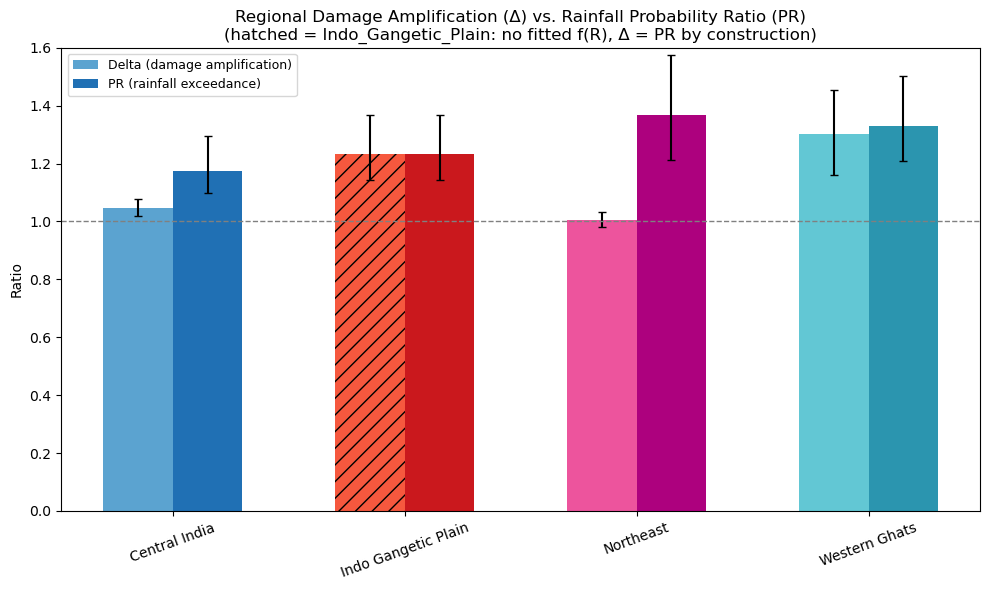

In [57]:
import matplotlib.cm as cm

region_cmaps = {
    'Central_India': cm.Blues,
    'Indo_Gangetic_Plain': cm.Reds,
    'Northeast': cm.RdPu,
    'Western_Ghats': cm.GnBu,
}

MANUAL_METRIC_COLORS = {
    'Western_Ghats': ["#AEE6E3", "#62C7D4", "#2B95AF", "#116B86"],
}

pr_ci = pr_df_prfirst[pr_df_prfirst.year == PRESENT_DAY_WINDOW].set_index('region')
delta_lookup = delta_results.set_index('region')

fig, ax = plt.subplots(figsize=(10, 6))

width = 0.3
x = np.arange(len(REGION_ORDER))
hatches = ['' if r != 'Indo_Gangetic_Plain' else '//' for r in REGION_ORDER]

metric_shades = {}
for region in REGION_ORDER:
    if region in MANUAL_METRIC_COLORS:
        metric_shades[region] = MANUAL_METRIC_COLORS[region]
    else:
        cmap = region_cmaps[region]
        metric_shades[region] = [cmap(f) for f in [0.35, 0.55, 0.75, 0.95]]

delta_colors = [metric_shades[r][1] for r in REGION_ORDER]
pr_colors = [metric_shades[r][2] for r in REGION_ORDER]

pr_vals = pr_ci.loc[REGION_ORDER, 'PR']
pr_err = [pr_vals - pr_ci.loc[REGION_ORDER, 'PR_ci_5'], pr_ci.loc[REGION_ORDER, 'PR_ci_95'] - pr_vals]

delta_vals = delta_lookup.loc[REGION_ORDER, 'delta']
delta_err = [delta_vals - delta_lookup.loc[REGION_ORDER, 'delta_ci_5'],
             delta_lookup.loc[REGION_ORDER, 'delta_ci_95'] - delta_vals]

bars_delta = ax.bar(x - width/2, delta_vals, width, yerr=delta_err, capsize=3, label='Delta (damage amplification)', color=delta_colors)
bars_pr = ax.bar(x + width/2, pr_vals, width, yerr=pr_err, capsize=3, label='PR (rainfall exceedance)', color=pr_colors)

for bar, hatch in zip(bars_delta, hatches):
    bar.set_hatch(hatch)

ax.axhline(1, color='grey', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([r.replace('_', ' ') for r in REGION_ORDER], rotation=20)
ax.set_ylabel('Ratio')
ax.set_title('Regional Damage Amplification (Δ) vs. Rainfall Probability Ratio (PR)\n'
              '(hatched = Indo_Gangetic_Plain: no fitted f(R), Δ = PR by construction)')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.6)

plt.tight_layout()
# Reported in the dissertation as Figure 25
plt.savefig(OUTPUT_DIR + 'figure_pr_vs_delta_simple.png', dpi=150, bbox_inches='tight')
plt.show()

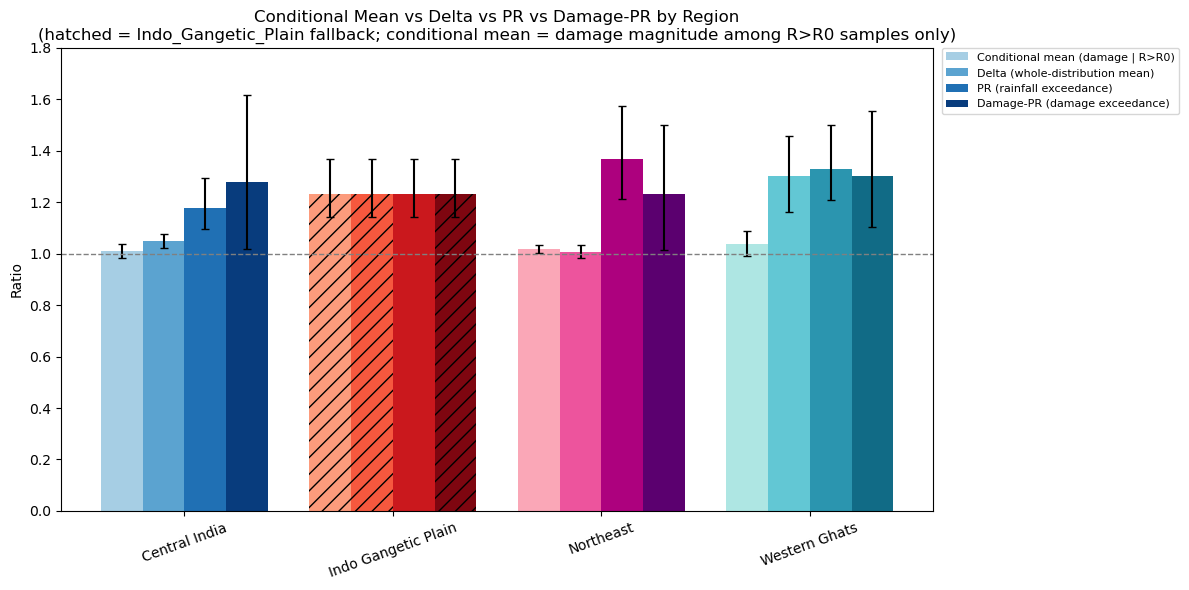

In [58]:
import matplotlib.cm as cm

region_cmaps = {
    'Central_India': cm.Blues,
    'Indo_Gangetic_Plain': cm.Reds,
    'Northeast': cm.RdPu,
    'Western_Ghats': cm.GnBu,
}

MANUAL_METRIC_COLORS = {
    'Western_Ghats': ["#AEE6E3", "#62C7D4", "#2B95AF", "#116B86"],
}

# Rebuilt here rather than reused, to avoid stale values if an earlier cell was re-run out of order
pr_ci = pr_df_prfirst[pr_df_prfirst.year == PRESENT_DAY_WINDOW].set_index('region')

damage_pr_lookup = damage_pr_df.set_index('region').copy()
damage_pr_lookup.loc['Indo_Gangetic_Plain', 'damage_PR'] = pr_ci.loc['Indo_Gangetic_Plain', 'PR']
damage_pr_lookup.loc['Indo_Gangetic_Plain', ['damage_pr_ci_5', 'damage_pr_ci_95']] = pr_ci.loc['Indo_Gangetic_Plain', ['PR_ci_5', 'PR_ci_95']].values

cond_lookup = conditional_mean_df.set_index('region').copy()
cond_lookup.loc['Indo_Gangetic_Plain', 'conditional_mean_ratio'] = pr_ci.loc['Indo_Gangetic_Plain', 'PR']
cond_lookup.loc['Indo_Gangetic_Plain', ['conditional_ci_5', 'conditional_ci_95']] = pr_ci.loc['Indo_Gangetic_Plain', ['PR_ci_5', 'PR_ci_95']].values

delta_lookup = delta_results.set_index('region')

fig, ax = plt.subplots(figsize=(12, 6))

width = 0.2
x = np.arange(len(REGION_ORDER))
hatches = ['' if r != 'Indo_Gangetic_Plain' else '//' for r in REGION_ORDER]

metric_shades = {}
for region in REGION_ORDER:
    if region in MANUAL_METRIC_COLORS:
        metric_shades[region] = MANUAL_METRIC_COLORS[region]
    else:
        cmap = region_cmaps[region]
        metric_shades[region] = [cmap(f) for f in [0.35, 0.55, 0.75, 0.95]]

cond_colors = [metric_shades[r][0] for r in REGION_ORDER]
delta_colors = [metric_shades[r][1] for r in REGION_ORDER]
pr_colors = [metric_shades[r][2] for r in REGION_ORDER]
dpr_colors = [metric_shades[r][3] for r in REGION_ORDER]

pr_vals = pr_ci.loc[REGION_ORDER, 'PR']
pr_err = [pr_vals - pr_ci.loc[REGION_ORDER, 'PR_ci_5'], pr_ci.loc[REGION_ORDER, 'PR_ci_95'] - pr_vals]

dpr_vals = damage_pr_lookup.loc[REGION_ORDER, 'damage_PR']
dpr_err = [dpr_vals - damage_pr_lookup.loc[REGION_ORDER, 'damage_pr_ci_5'],
           damage_pr_lookup.loc[REGION_ORDER, 'damage_pr_ci_95'] - dpr_vals]

cond_vals = cond_lookup.loc[REGION_ORDER, 'conditional_mean_ratio']
cond_err = [cond_vals - cond_lookup.loc[REGION_ORDER, 'conditional_ci_5'],
            cond_lookup.loc[REGION_ORDER, 'conditional_ci_95'] - cond_vals]

delta_vals = delta_lookup.loc[REGION_ORDER, 'delta']
delta_err = [delta_vals - delta_lookup.loc[REGION_ORDER, 'delta_ci_5'],
             delta_lookup.loc[REGION_ORDER, 'delta_ci_95'] - delta_vals]

bars_cond = ax.bar(x - 1.5*width, cond_vals, width, yerr=cond_err, capsize=3, label='Conditional mean (damage | R>R0)', color=cond_colors)
bars_delta = ax.bar(x - 0.5*width, delta_vals, width, yerr=delta_err, capsize=3, label='Delta (whole-distribution mean)', color=delta_colors)
bars_pr = ax.bar(x + 0.5*width, pr_vals, width, yerr=pr_err, capsize=3, label='PR (rainfall exceedance)', color=pr_colors)
bars_dpr = ax.bar(x + 1.5*width, dpr_vals, width, yerr=dpr_err, capsize=3, label='Damage-PR (damage exceedance)', color=dpr_colors)

for bars in [bars_cond, bars_delta, bars_dpr]:
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)

ax.axhline(1, color='grey', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([r.replace('_', ' ') for r in REGION_ORDER], rotation=20)
ax.set_ylabel('Ratio')
ax.set_title('Conditional Mean vs Delta vs PR vs Damage-PR by Region\n'
              '(hatched = Indo_Gangetic_Plain fallback; conditional mean = damage magnitude among R>R0 samples only)')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.set_ylim(0, 1.8)

plt.tight_layout()
# Reported in the dissertation as Figure 27
plt.savefig(OUTPUT_DIR + 'figure9d_pr_damagepr_conditional_delta.png', dpi=150, bbox_inches='tight')
plt.show()

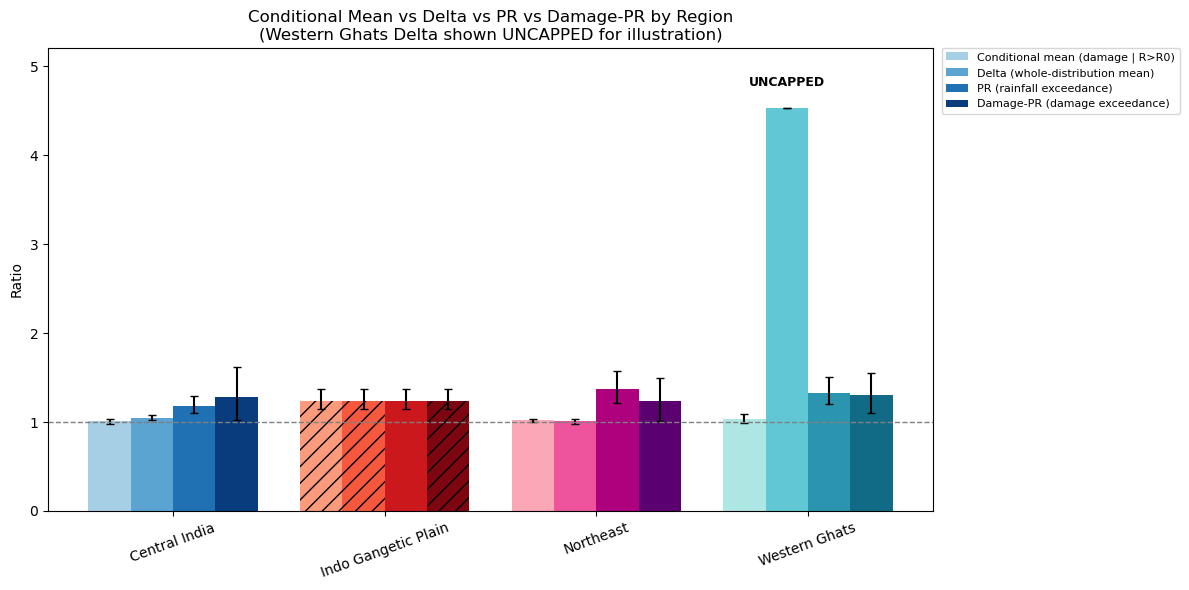

In [59]:
import matplotlib.cm as cm

region_cmaps = {
    'Central_India': cm.Blues,
    'Indo_Gangetic_Plain': cm.Reds,
    'Northeast': cm.RdPu,
    'Western_Ghats': cm.GnBu,
}

MANUAL_METRIC_COLORS = {
    'Western_Ghats': ["#AEE6E3", "#62C7D4", "#2B95AF", "#116B86"],
}

UNCAPPED_WESTERN_GHATS_DELTA = 4.529168

# Self-contained rebuilds
pr_ci = pr_df_prfirst[pr_df_prfirst.year == PRESENT_DAY_WINDOW].set_index('region')

damage_pr_lookup = damage_pr_df.set_index('region').copy()
damage_pr_lookup.loc['Indo_Gangetic_Plain', 'damage_PR'] = pr_ci.loc['Indo_Gangetic_Plain', 'PR']
damage_pr_lookup.loc['Indo_Gangetic_Plain', ['damage_pr_ci_5', 'damage_pr_ci_95']] = pr_ci.loc['Indo_Gangetic_Plain', ['PR_ci_5', 'PR_ci_95']].values

cond_lookup = conditional_mean_df.set_index('region').copy()
cond_lookup.loc['Indo_Gangetic_Plain', 'conditional_mean_ratio'] = pr_ci.loc['Indo_Gangetic_Plain', 'PR']
cond_lookup.loc['Indo_Gangetic_Plain', ['conditional_ci_5', 'conditional_ci_95']] = pr_ci.loc['Indo_Gangetic_Plain', ['PR_ci_5', 'PR_ci_95']].values

delta_lookup_uncapped = delta_results.set_index('region').copy()
delta_lookup_uncapped.loc['Western_Ghats', 'delta'] = UNCAPPED_WESTERN_GHATS_DELTA
delta_lookup_uncapped.loc['Western_Ghats', ['delta_ci_5', 'delta_ci_95']] = UNCAPPED_WESTERN_GHATS_DELTA
# end rebuilds

fig, ax = plt.subplots(figsize=(12, 6))

width = 0.2
x = np.arange(len(REGION_ORDER))
hatches = ['' if r != 'Indo_Gangetic_Plain' else '//' for r in REGION_ORDER]

metric_shades = {}
for region in REGION_ORDER:
    if region in MANUAL_METRIC_COLORS:
        metric_shades[region] = MANUAL_METRIC_COLORS[region]
    else:
        cmap = region_cmaps[region]
        metric_shades[region] = [cmap(f) for f in [0.35, 0.55, 0.75, 0.95]]

cond_colors = [metric_shades[r][0] for r in REGION_ORDER]
delta_colors = [metric_shades[r][1] for r in REGION_ORDER]
pr_colors = [metric_shades[r][2] for r in REGION_ORDER]
dpr_colors = [metric_shades[r][3] for r in REGION_ORDER]

pr_vals = pr_ci.loc[REGION_ORDER, 'PR']
pr_err = [pr_vals - pr_ci.loc[REGION_ORDER, 'PR_ci_5'], pr_ci.loc[REGION_ORDER, 'PR_ci_95'] - pr_vals]

dpr_vals = damage_pr_lookup.loc[REGION_ORDER, 'damage_PR']
dpr_err = [dpr_vals - damage_pr_lookup.loc[REGION_ORDER, 'damage_pr_ci_5'],
           damage_pr_lookup.loc[REGION_ORDER, 'damage_pr_ci_95'] - dpr_vals]

cond_vals = cond_lookup.loc[REGION_ORDER, 'conditional_mean_ratio']
cond_err = [cond_vals - cond_lookup.loc[REGION_ORDER, 'conditional_ci_5'],
            cond_lookup.loc[REGION_ORDER, 'conditional_ci_95'] - cond_vals]

delta_vals = delta_lookup_uncapped.loc[REGION_ORDER, 'delta']
delta_err = [delta_vals - delta_lookup_uncapped.loc[REGION_ORDER, 'delta_ci_5'],
             delta_lookup_uncapped.loc[REGION_ORDER, 'delta_ci_95'] - delta_vals]

bars_cond = ax.bar(x - 1.5*width, cond_vals, width, yerr=cond_err, capsize=3, label='Conditional mean (damage | R>R0)', color=cond_colors)
bars_delta = ax.bar(x - 0.5*width, delta_vals, width, yerr=delta_err, capsize=3, label='Delta (whole-distribution mean)', color=delta_colors)
bars_pr = ax.bar(x + 0.5*width, pr_vals, width, yerr=pr_err, capsize=3, label='PR (rainfall exceedance)', color=pr_colors)
bars_dpr = ax.bar(x + 1.5*width, dpr_vals, width, yerr=dpr_err, capsize=3, label='Damage-PR (damage exceedance)', color=dpr_colors)

for bars in [bars_cond, bars_delta, bars_dpr]:
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)

wg_idx = REGION_ORDER.index('Western_Ghats')
top_of_bar = UNCAPPED_WESTERN_GHATS_DELTA
ax.annotate('UNCAPPED', xy=(wg_idx - 0.5*width, top_of_bar),
            xytext=(wg_idx - 0.5*width, top_of_bar + 0.25),
            ha='center', fontsize=9, fontweight='bold')

ax.set_ylim(0, UNCAPPED_WESTERN_GHATS_DELTA * 1.15)

ax.axhline(1, color='grey', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([r.replace('_', ' ') for r in REGION_ORDER], rotation=20)
ax.set_ylabel('Ratio')
ax.set_title('Conditional Mean vs Delta vs PR vs Damage-PR by Region\n'
              '(Western Ghats Delta shown UNCAPPED for illustration)')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'slide5_uncapped_western_ghats.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h3 style="color: white; margin: 0; font-size: 18px;">Part 9c: Tail-Distribution Explainer (Figure 26)</h3>
</div>

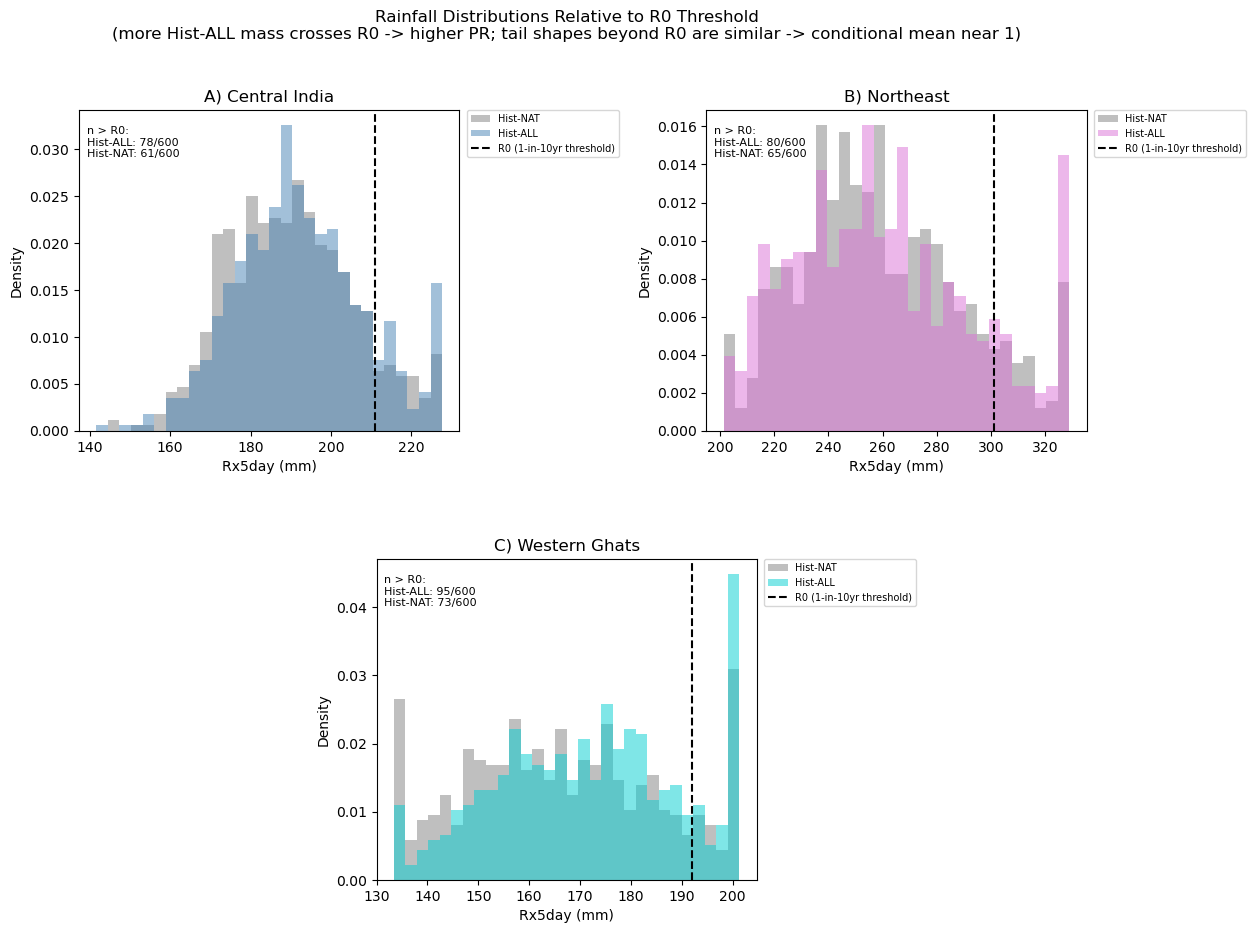

In [60]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(13, 10))
gs = GridSpec(2, 1, figure=fig, hspace=0.4)

gs_top = gs[0].subgridspec(1, 2, wspace=0.65)
ax_ci = fig.add_subplot(gs_top[0, 0])
ax_ne = fig.add_subplot(gs_top[0, 1])

# Placeholder position for Western Ghats, corrected below to match Panel A's real width
ax_wg = fig.add_subplot(gs[1])

axes = [ax_ci, ax_ne, ax_wg]
panel_letters = ['A)', 'B)', 'C)']

for ax, region, letter in zip(axes, FR_REGIONS, panel_letters):
    color = region_colors[region]
    r0 = R0_corrected[region]

    combined = np.concatenate([capped_ant[region], capped_nat[region]])
    bins = np.linspace(combined.min(), combined.max(), 31)

    ax.hist(capped_nat[region], bins=bins, color='grey', alpha=0.5, label='Hist-NAT', density=True)
    ax.hist(capped_ant[region], bins=bins, color=color, alpha=0.5, label='Hist-ALL', density=True)
    ax.axvline(r0, color='black', linestyle='--', linewidth=1.5, label='R0 (1-in-10yr threshold)')

    n_ant = (capped_ant[region] > r0).sum()
    n_nat = (capped_nat[region] > r0).sum()
    ax.text(0.02, 0.95, f'n > R0:\nHist-ALL: {n_ant}/600\nHist-NAT: {n_nat}/600',
            transform=ax.transAxes, ha='left', va='top', fontsize=8,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    ax.set_title(f'{letter} {region.replace("_", " ")}')
    ax.set_xlabel('Rx5day (mm)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

pos_a = ax_ci.get_position()
pos_wg = ax_wg.get_position()
new_x0 = 0.5 - pos_a.width / 2
ax_wg.set_position([new_x0, pos_wg.y0, pos_a.width, pos_wg.height])

fig.suptitle('Rainfall Distributions Relative to R0 Threshold\n'
              '(more Hist-ALL mass crosses R0 -> higher PR; tail shapes beyond R0 are similar -> conditional mean near 1)',
              fontsize=12)
plt.savefig(OUTPUT_DIR + 'figure_tail_distribution_explainer.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
for region in FR_REGIONS:
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    cap_max = obs.max()
    combined = np.concatenate([capped_ant[region], capped_nat[region]])
    bins = np.linspace(combined.min(), combined.max(), 31)
    last_bin_edge = bins[-2]

    ant_in_last_bin = np.sum(capped_ant[region] >= last_bin_edge)
    nat_in_last_bin = np.sum(capped_nat[region] >= last_bin_edge)
    ant_exactly_capped = np.sum(capped_ant[region] == cap_max)
    nat_exactly_capped = np.sum(capped_nat[region] == cap_max)

    print(f"{region}: last bin -> ALL={ant_in_last_bin}, NAT={nat_in_last_bin} | "
          f"exactly at cap -> ALL={ant_exactly_capped}, NAT={nat_exactly_capped}")

Central_India: last bin -> ALL=27, NAT=14 | exactly at cap -> ALL=16, NAT=9
Northeast: last bin -> ALL=37, NAT=20 | exactly at cap -> ALL=33, NAT=16
Western_Ghats: last bin -> ALL=61, NAT=42 | exactly at cap -> ALL=53, NAT=36


In [62]:
delta_final = pd.read_csv(OUTPUT_DIR + 'damage_amplification_results.csv')
print(delta_final)

                region                         method  PR_present     delta  \
0        Central_India               f(R) propagation    1.175537  1.048110   
1  Indo_Gangetic_Plain  FAR x AAL fallback (Delta=PR)    1.232232  1.232232   
2            Northeast               f(R) propagation    1.366995  1.006156   
3        Western_Ghats               f(R) propagation    1.328223  1.301242   

   delta_ci_5  delta_ci_95  pct_capped_ant  pct_capped_nat  delta_rank  \
0    1.020233     1.076528        2.666667        1.500000           3   
1    1.142625     1.367198             NaN             NaN           2   
2    0.981064     1.034153        6.333333        4.166667           4   
3    1.159800     1.455285       10.500000       10.333333           1   

   PR_rank  
0        4  
1        3  
2        1  
3        2  


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 10: SSP2-4.5 Exploration</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Illustrative content only, not a robust attribution result; future PR/Delta is out of scope (no Hist-NAT equivalent exists for the future period). 2-panel figure: SSP2-4.5 Rx5day projection, and that same rainfall pushed through the fitted damage function f(R). IGP included in the rainfall panel only (no fitted f(R) to propagate through).</p>
</div>

In [63]:
rx5day_ssp245 = xr.open_dataset(OUTPUT_DIR + 'rx5day_ssp245_regional.nc')

# IGP's own scale factor (not in bias_df, needs separate computation)
rx5day_era5_full = xr.open_dataset(OUTPUT_DIR + 'rx5day_era5_regional.nc').assign_coords(region=REGION_ORDER)
rx5day_ant_full = xr.open_dataset(OUTPUT_DIR + 'rx5day_ant_regional.nc')

OVERLAP_YEARS = slice(2000, 2014)
mpi_overlap_igp = rx5day_ant_full['rx5day_ant_regional'].isel(
    region=REGION_ORDER.index('Indo_Gangetic_Plain')).sel(year=OVERLAP_YEARS).values.flatten()
mpi_mean_igp = np.mean(mpi_overlap_igp)

era5_overlap_igp = rx5day_era5_full['rx5day'].sel(
    region='Indo_Gangetic_Plain', year=OVERLAP_YEARS).values.flatten()
era5_mean_igp = np.mean(era5_overlap_igp)
scale_factor_igp = era5_mean_igp / mpi_mean_igp

scale_factors_all = {row.region: row.scale_factor for row in bias_df.itertuples()}
scale_factors_all['Indo_Gangetic_Plain'] = scale_factor_igp

ssp245_corrected = {}
for region in REGION_ORDER:
    ssp245_corrected[region] = rx5day_ssp245['rx5day_ssp245_regional'].sel(region=region) * scale_factors_all[region]

print("Setup complete:", list(scale_factors_all.items()))

Setup complete: [('Central_India', 1.6065784620338606), ('Northeast', 1.8323224420342095), ('Western_Ghats', 1.839100265824395), ('Indo_Gangetic_Plain', np.float64(1.6135392368139783))]


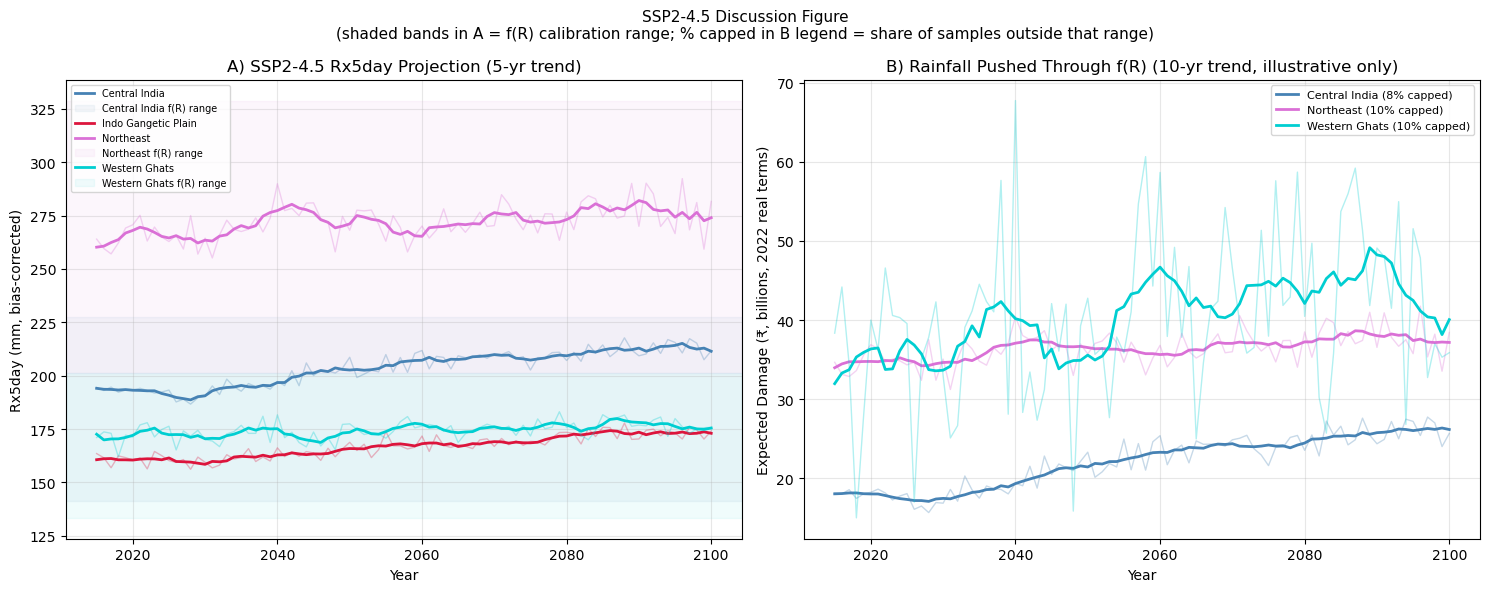

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: SSP2-4.5 Rx5day projection, all 4 regions, all bias-corrected
ax = axes[0]
for region in REGION_ORDER:
    color = region_colors[region]
    da = ssp245_corrected[region]
    ensemble_mean = da.mean(dim='member')
    trend = ensemble_mean.to_pandas().rolling(5, center=True, min_periods=1).mean()

    ax.plot(da.year, ensemble_mean, color=color, linewidth=1, alpha=0.3, label='_nolegend_')
    ax.plot(da.year, trend, color=color, linewidth=2, label=region.replace('_', ' '))

    if region in FR_REGIONS:
        obs = fR_input[fR_input.region == region]['rx5day_mm']
        ax.axhspan(obs.min(), obs.max(), color=color, alpha=0.06, label=f'{region.replace("_", " ")} f(R) range')

ax.set_xlabel('Year')
ax.set_ylabel('Rx5day (mm, bias-corrected)')
ax.set_title('A) SSP2-4.5 Rx5day Projection (5-yr trend)')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Panel B: same rainfall pushed through f(R), 3 fitted regions only
ax2 = axes[1]
for region in FR_REGIONS:
    color = region_colors[region]
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    obs_min, obs_max = obs.min(), obs.max()

    da = ssp245_corrected[region]
    capped = da.clip(min=obs_min, max=obs_max)
    pct_capped = 100 * float((da < obs_min).sum() + (da > obs_max).sum()) / da.size

    damage = xr.apply_ufunc(lambda r: evaluate_fR(region, r, fR_params), capped, vectorize=True)
    damage_inr_bn = damage * 1e7 / 1e9
    ensemble_mean_damage = damage_inr_bn.mean(dim='member')
    trend = ensemble_mean_damage.to_pandas().rolling(10, center=True, min_periods=1).mean()

    ax2.plot(da.year, ensemble_mean_damage, color=color, linewidth=1, alpha=0.3, label='_nolegend_')
    ax2.plot(da.year, trend, color=color, linewidth=2,
             label=f'{region.replace("_", " ")} ({pct_capped:.0f}% capped)')

ax2.set_xlabel('Year')
ax2.set_ylabel('Expected Damage (₹, billions, 2022 real terms)')
ax2.set_title('B) Rainfall Pushed Through f(R) (10-yr trend, illustrative only)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.suptitle('SSP2-4.5 Discussion Figure\n'
              '(shaded bands in A = f(R) calibration range; % capped in B legend = share of samples outside that range)',
              fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure_ssp245_discussion.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
print(f"{'Region':<18} {'2015 trend (mm)':<18} {'2100 trend (mm)':<18} {'f(R) range (mm)'}")
for region in REGION_ORDER:
    da = ssp245_corrected[region]
    ensemble_mean = da.mean(dim='member')
    trend = ensemble_mean.to_pandas().rolling(5, center=True, min_periods=1).mean()

    val_2015 = trend.loc[2015]
    val_2100 = trend.loc[2100]

    if region in FR_REGIONS:
        obs = fR_input[fR_input.region == region]['rx5day_mm']
        fr_range = f"{obs.min():.2f} - {obs.max():.2f}"
    else:
        fr_range = "N/A (no fitted f(R))"

    print(f"{region:<18} {val_2015:<18.3f} {val_2100:<18.3f} {fr_range}")

print()
print(f"{'Region':<18} {'2015 damage (Cr)':<18} {'2100 damage (Cr)':<18} {'% capped'}")
for region in FR_REGIONS:
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    obs_min, obs_max = obs.min(), obs.max()

    da = ssp245_corrected[region]
    capped = da.clip(min=obs_min, max=obs_max)
    pct_capped = 100 * float((da < obs_min).sum() + (da > obs_max).sum()) / da.size

    damage = xr.apply_ufunc(lambda r: evaluate_fR(region, r, fR_params), capped, vectorize=True)
    ensemble_mean_damage = damage.mean(dim='member')
    trend_damage = ensemble_mean_damage.to_pandas().rolling(10, center=True, min_periods=1).mean()

    val_2015 = trend_damage.loc[2015]
    val_2100 = trend_damage.loc[2100]

    print(f"{region:<18} {val_2015:<18.2f} {val_2100:<18.2f} {pct_capped:.3f}%")

Region             2015 trend (mm)    2100 trend (mm)    f(R) range (mm)
Central_India      194.080            211.452            141.12 - 227.60
Indo_Gangetic_Plain 160.628            173.004            N/A (no fitted f(R))
Northeast          260.222            274.027            201.40 - 328.91
Western_Ghats      172.568            175.468            133.38 - 201.34

Region             2015 damage (Cr)   2100 damage (Cr)   % capped
Central_India      1805.77            2618.27            8.140%
Northeast          3398.04            3717.84            9.690%
Western_Ghats      3197.15            4005.71            10.426%


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Summary</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Regional damage amplification ratios (Delta) computed by propagating bias-corrected, present-day MPI rainfall through each region's fitted f(R), with capping applied to prevent extrapolation blowup. Indo-Gangetic Plain has no reliable fit and falls back to Delta=PR. Northeast shows a strong rainfall signal (PR 1.37) that mostly doesn't survive into damage (Delta 1.01); Western Ghats shows the closest correspondence between the two (PR 1.33, Delta 1.30). Full results saved to damage_amplification_results.csv; comparison figure saved to figure_pr_vs_delta_simple.png (Figure 25).</p>
</div>